In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [4]:
df=pd.read_csv("wine_data.csv",header=None,usecols=[0,1,2])

In [6]:
df.columns=['class_label','alcohol','malic_acid']

In [7]:
df

,class_label,alcohol,malic_acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='alcohol', ylabel='Density'>

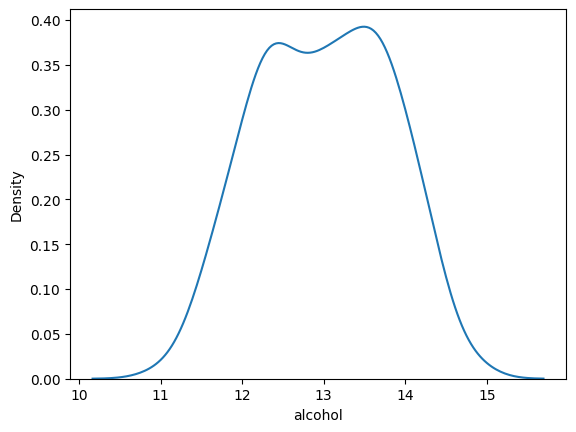

In [8]:
sns.kdeplot(df['alcohol'])

<Axes: xlabel='malic_acid', ylabel='Density'>

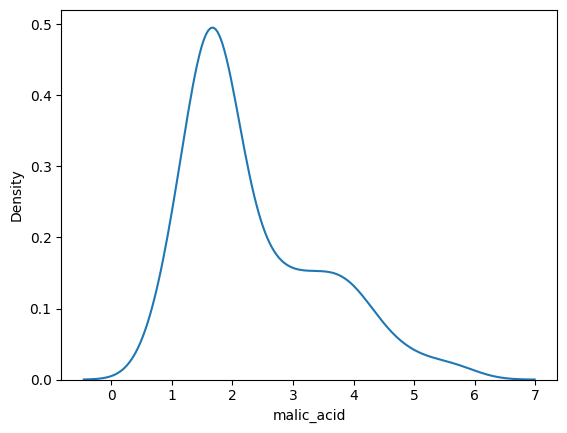

In [9]:
sns.kdeplot(df['malic_acid'])

<Axes: xlabel='alcohol', ylabel='malic_acid'>

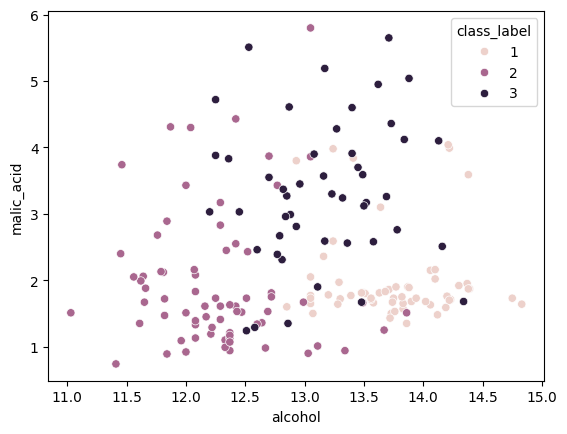

In [11]:
sns.scatterplot(x=df['alcohol'],y=df['malic_acid'],hue=df['class_label'])

In [13]:
x=df.drop(columns=['class_label'])
y=df['class_label']

0      1
1      1
2      1
3      1
4      1
      ..
173    3
174    3
175    3
176    3
177    3
Name: class_label, Length: 178, dtype: int64

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [18]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [19]:
x_train_scaled

array([[0.71505376, 0.51323829],
       [0.44623656, 0.16089613],
       [0.15860215, 0.25458248],
       [0.63709677, 0.64562118],
       [0.66397849, 0.21792261],
       [0.72580645, 0.15478615],
       [0.33870968, 0.42566191],
       [0.42204301, 0.12219959],
       [0.10215054, 0.        ],
       [0.7016129 , 0.48065173],
       [0.42204301, 0.3503055 ],
       [0.25      , 0.0712831 ],
       [0.32795699, 0.6395112 ],
       [0.87903226, 0.24032587],
       [0.49731183, 0.45824847],
       [0.66129032, 0.58044807],
       [0.68010753, 0.19755601],
       [0.88978495, 0.19144603],
       [0.72043011, 0.22810591],
       [0.31989247, 0.11201629],
       [0.60215054, 0.7209776 ],
       [0.57258065, 0.57637475],
       [0.76075269, 0.15682281],
       [0.48924731, 0.51527495],
       [0.75537634, 0.68839104],
       [0.61021505, 0.19959267],
       [0.54301075, 0.63543788],
       [0.39784946, 0.10183299],
       [0.33870968, 0.13645621],
       [0.46774194, 0.54786151],
       [0.

Text(0.5, 1.0, 'after scalling ')

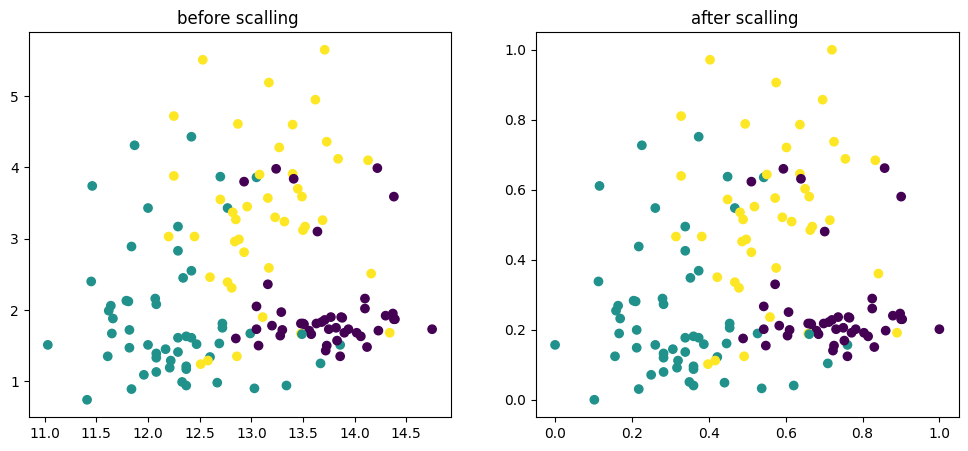

In [31]:
fig, (ax1,ax2)=plt.subplots(figsize=(12,5),ncols=2)
ax1.scatter(x_train['alcohol'],x_train['malic_acid'],c=y_train)
ax1.set_title('before scalling ')
ax2.scatter(x_train_scaled[:,0],x_train_scaled[:,1],c=y_train)
ax2.set_title('after scalling ')

# accuracy score improve after scalling practical

In [32]:
from sklearn.linear_model import LogisticRegression

In [38]:
model=LogisticRegression()
model2=LogisticRegression()
model2.fit(x_train_scaled,y_train)
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [39]:
y_pred=model.predict(x_test)
y_pred2=model2.predict(x_test_scaled)

In [41]:
from sklearn.metrics import accuracy_score
print("before scalling",accuracy_score(y_test,y_pred))
print("after_scaliing",accuracy_score(y_test,y_pred2))

before scalling 0.7222222222222222
after_scaliing 0.75
